### Main Workflow

In [1]:
# load modules
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np
from datetime import datetime, timedelta

# coastsat modules
sys.path.insert(0, os.pardir)
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_classify

# EDA utils
import modified_coastsat # modifications for SWIR1 imagery
from indices import *
from thresholding import *
from plotting import (
    plot_indices, 
    plot_samples,
    plot_extractions,
    sample_ms,
    save_all_plots
)
from image_plotting_parameters import (
    get_image_plotting_params,
    fn_to_title,
    get_idx_for_site,
    get_download_dict,
    get_paths
)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [36]:
def init_dir_structure(output_dir):
    data_dir = os.path.join(output_dir, "data")
    aoi_dir = os.path.join(data_dir, "aoi")
    ref_sl_dir = os.path.join(data_dir, "ref_sl")
    plots_dir = os.path.join(output_dir, "plots")

    os.makedirs(data_dir, exist_ok=True)
    os.makedirs(aoi_dir, exist_ok=True)
    os.makedirs(ref_sl_dir, exist_ok=True)
    os.makedirs(plots_dir, exist_ok=True)

def init_site(sitename, output_epsg, output_dir):
    dl_dict = get_download_dict(sitename)

    # you will have to modify paths if you're not me
    aoi_path, ref_sl_path = get_paths(sitename, output_dir)

    data_path = os.path.join(output_dir, "data", sitename)
    polygon = SDS_tools.polygon_from_kml(aoi_path)
    polygon = SDS_tools.smallest_rectangle(polygon)
    ref_sl = SDS_preprocess.get_reference_sl_from_geojson(ref_sl_path, output_epsg)

    return dl_dict, data_path, ref_sl, polygon

def download(sitename, dl_dict, data_path, polygon):
    one_day = timedelta(days=1)
    format = "%Y-%m-%d"
    for satname in dl_dict.keys():
        for date in dl_dict[satname]:
            date_range = [date.strftime(format), (date + one_day).strftime(format)]

            cur_inputs = {
                'dates': date_range,
                'sat_list': [satname],
                'filepath': data_path,
                'sitename': sitename,
                'polygon': polygon
            }
            modified_coastsat.retrieve_images(cur_inputs)

    inputs = {
        'filepath': data_path,
        'sitename': sitename
    }
    return SDS_download.get_metadata(inputs), inputs

def load_and_preprocess(metadata, inputs, buffer_settings):
    ims = []
    cloud_masks = []
    fns = []
    georefs = []
    im_buffers = []
    im_nodatas = []
    im_epsgs = []

    for satname in metadata.keys():
        filenames = metadata[satname]['filenames']
        filepath = modified_coastsat.get_filepath(inputs, satname)

        for i in range(len(filenames)):
            fn = modified_coastsat.get_filenames(filenames[i], filepath, satname)


            im_ms, georef, cloud_mask, im_extra, im_QA, im_nodata = modified_coastsat.preprocess_single(
                            fn, satname, cloud_mask_issue=False, pan_off=False, s2cloudless_prob=60)

            im_buffer = SDS_shoreline.create_shoreline_buffer(cloud_mask.shape, georef, metadata[satname]['epsg'][i], buffer_settings)

            ims.append(im_ms)
            cloud_masks.append(cloud_mask)
            fns.append(fn)
            georefs.append(georef)
            im_buffers.append(im_buffer)
            im_nodatas.append(im_nodata)
            im_epsgs.append(metadata[satname]['epsg'][i])

    return ims, cloud_masks, fns, georefs, im_buffers, im_nodatas, im_epsgs

def save_all_sites(sitenames, output_epsgs, output_dir, index_funcs, thresh_funcs):

    for sitename, output_epsg in zip(sitenames, output_epsgs):
        print(f"{sitename}...")
        dl_dict, data_path, ref_sl, polygon = init_site(sitename, output_epsg, output_dir)
        buffer_settings = {
            'output_epsg': output_epsg,
            'reference_shoreline': ref_sl,
            'max_dist_ref': 400,
            'min_length_sl': 500,
            'dist_clouds': 30,
        }
        metadata, inputs = download(sitename, dl_dict, data_path, polygon)
        ims, cloud_masks, fns, georefs, im_buffers, im_nodatas, im_epsgs = load_and_preprocess(metadata, inputs, buffer_settings)
        save_all_plots(sitename, fns, ims, cloud_masks, im_buffers, im_nodatas, georefs,
                    im_epsgs, index_funcs, thresh_funcs, buffer_settings, output_dir)

In [37]:
output_dir = "C:\\Users\\avanever\\Documents\\CoastSatProject\\Testing\\spectral_analysis_test"
sitenames = ["mini-rose-spit", "mini-island-view", "gas-cliff"]
output_epsgs = [3156, 3157, 3159]

init_dir_structure(output_dir)

You will need to fill the 'aoi' and 'ref_sl' directories with aoi kml and reference shoreline shapefiles corresponding to the sites

In [38]:
index_funcs = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
thresh_funcs = [
    otsu,
    local_min_otsu
]
save_all_sites(sitenames, output_epsgs, output_dir, index_funcs, thresh_funcs)

mini-rose-spit...
Reference shorelines found in GeoJSON. Loading coordinates for each feature.
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Testing\spectral_analysis_test\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Testing\spectral_analysis_test\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Testing\spectral_analysis_test\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Testing\spectral_analysis_test\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Testing\spectral_analysis_test\data\mini-rose-spit
GEE initialized

### For Messing Around

In [ ]:
output_dir = "C:\\Users\\avanever\\Documents\\CoastSatProject\\spectral_analysis"
sitename = "mini-rose-spit"
output_epsg = 3156
dl_dict, data_path, ref_sl, polygon = init_site(sitename, output_epsg, output_dir)

Reference shorelines found in GeoJSON. Loading coordinates for each feature.


In [13]:
metadata, inputs = download(sitename, dl_dict, data_path, polygon)

GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\spectral_analysis\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\spectral_analysis\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\spectral_analysis\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\spectral_analysis\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\spectral_analysis\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\spectral_analysis\data\mini-rose-spit
GEE initia

In [14]:
buffer_settings = {
    'output_epsg': output_epsg,
    'reference_shoreline': ref_sl,
    'max_dist_ref': 400,
    'min_length_sl': 500,
    'dist_clouds': 30,
}
ims, cloud_masks, fns, georefs, im_buffers, im_nodatas, im_epsgs = load_and_preprocess(metadata, inputs, buffer_settings)

['C:\\Users\\avanever\\Documents\\CoastSatProject\\spectral_analysis\\data\\mini-rose-spit\\S2\\ms\\2016-05-13-19-59-48_S2_09UUA_mini-rose-spit_ms.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\spectral_analysis\\data\\mini-rose-spit\\S2\\swir1\\2016-05-13-19-59-48_S2_09UUA_mini-rose-spit_swir1.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\spectral_analysis\\data\\mini-rose-spit\\S2\\swir2\\2016-05-13-19-59-48_S2_09UUA_mini-rose-spit_swir2.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\spectral_analysis\\data\\mini-rose-spit\\S2\\mask\\2016-05-13-19-59-48_S2_09UUA_mini-rose-spit_mask.tif']
['C:\\Users\\avanever\\Documents\\CoastSatProject\\spectral_analysis\\data\\mini-rose-spit\\S2\\ms\\2016-05-13-20-00-02_S2_09UUV_mini-rose-spit_ms.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\spectral_analysis\\data\\mini-rose-spit\\S2\\swir1\\2016-05-13-20-00-02_S2_09UUV_mini-rose-spit_swir1.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\spectral_analy

2002-08-29-19-37-16_L7_055022_mini-rose-spit


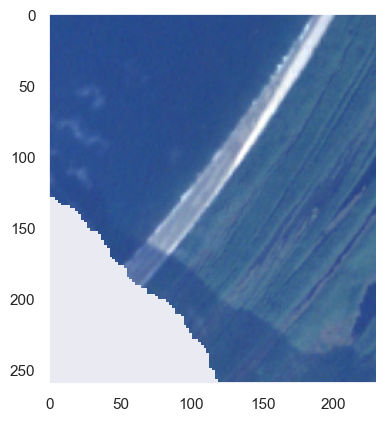

In [16]:
im_idx = 3
im_RGB = SDS_preprocess.rescale_image_intensity(ims[im_idx][:,:,[2,1,0]], cloud_masks[im_idx], 99.9)
print(fn_to_title(fns[im_idx][0], sitename))
plt.imshow(im_RGB)
plt.grid(False)

2002-08-29-19-37-16_L7_055022_mini-rose-spit


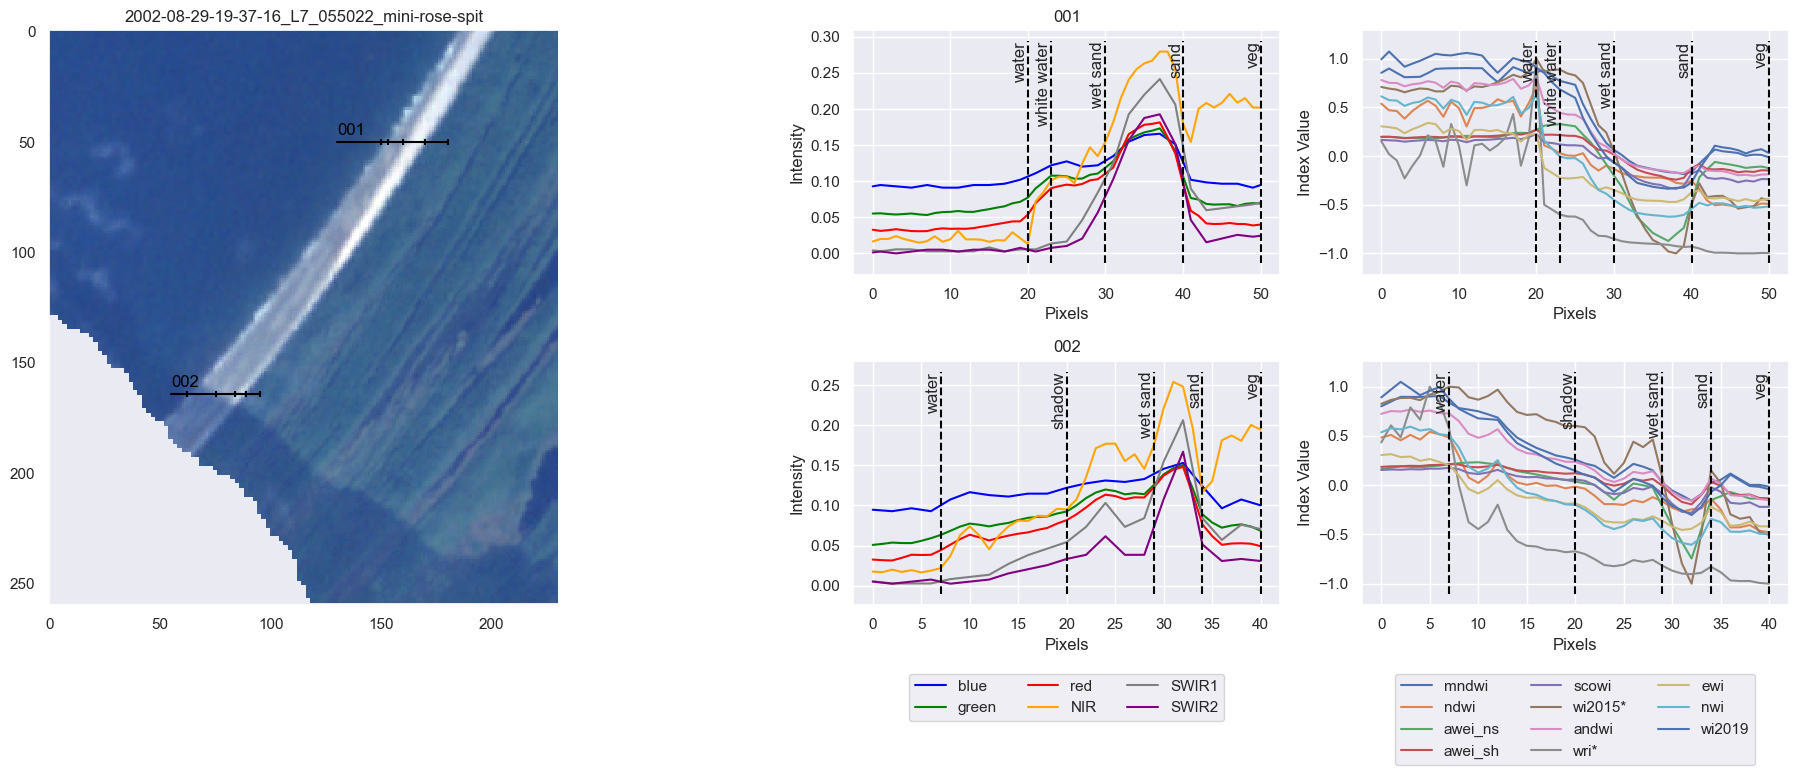

In [28]:
t, b_points, b_labs, sl_points, t_labs = get_image_plotting_params(sitename, im_idx)
title=fn_to_title(fns[im_idx][0], sitename)
samples = sample_ms(ims[im_idx], t)
print(title)
index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
plot_samples(ims[im_idx], title, cloud_masks[im_idx], t, samples, b_points, b_labs, t_labs, index_functions)

2002-08-29-19-37-16_L7_055022_mini-rose-spit


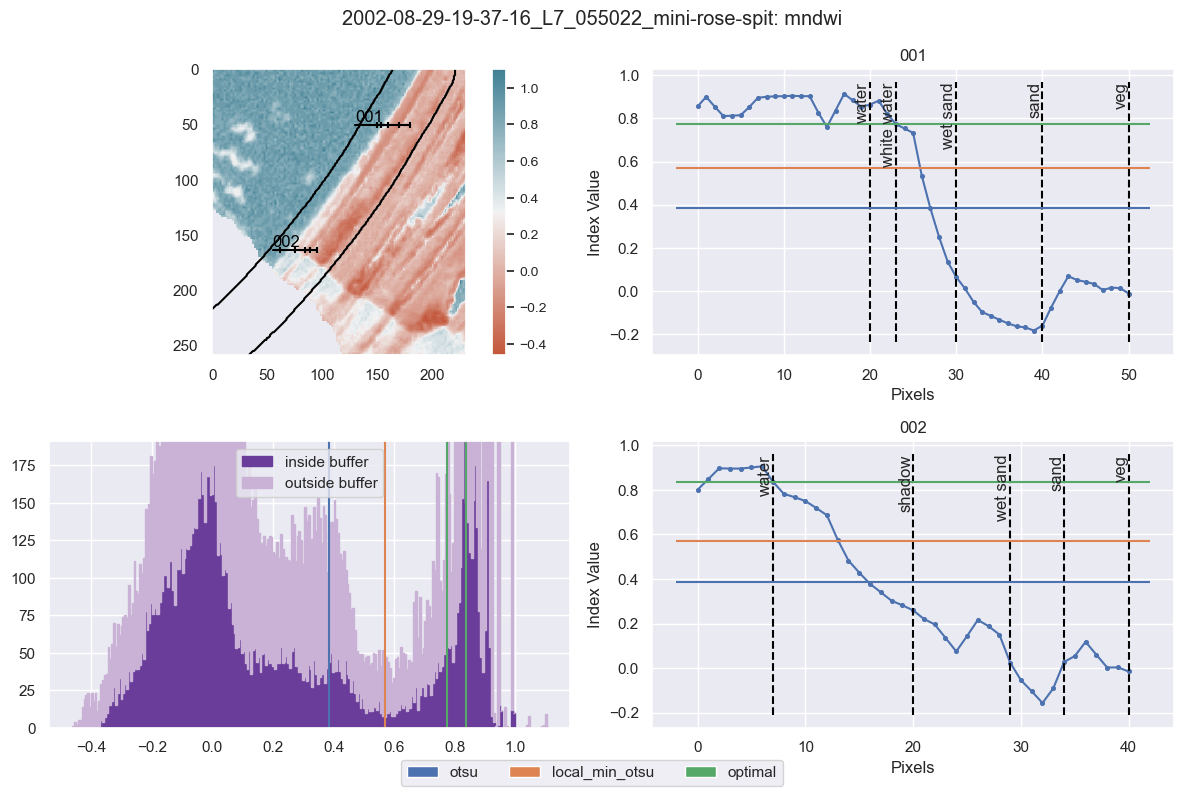

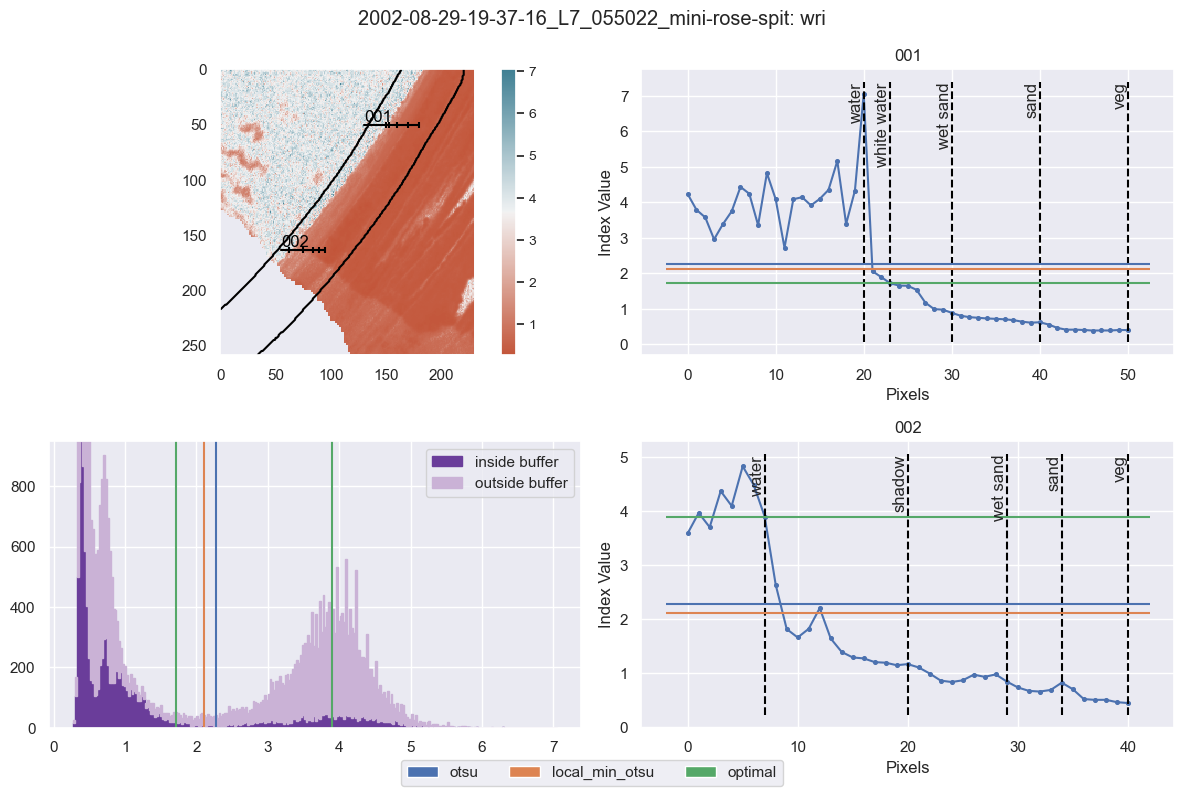

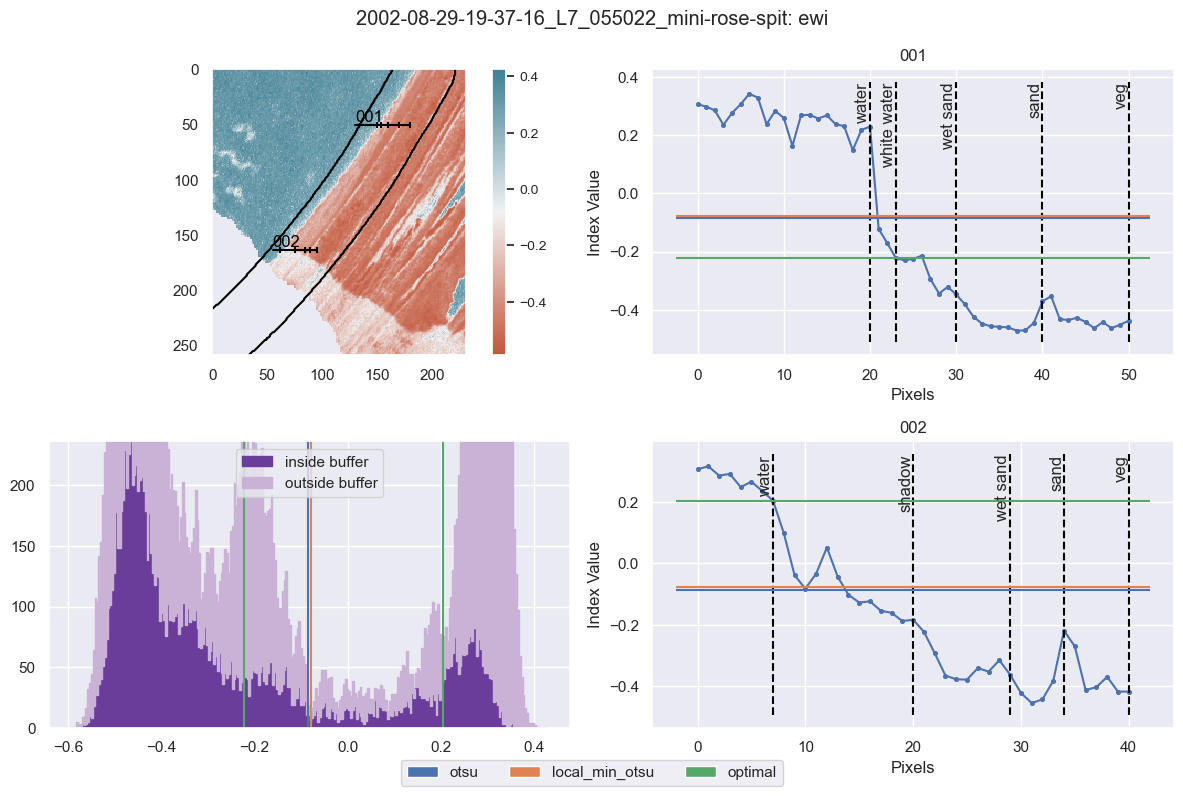

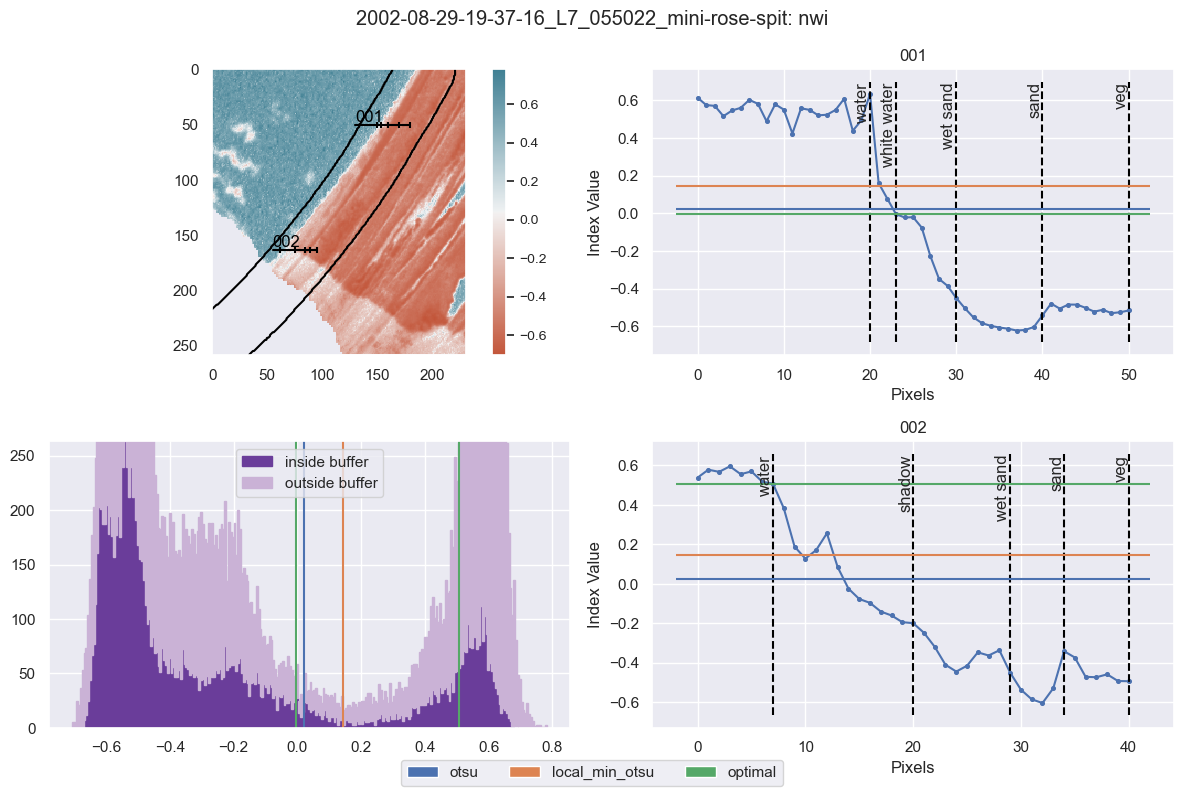

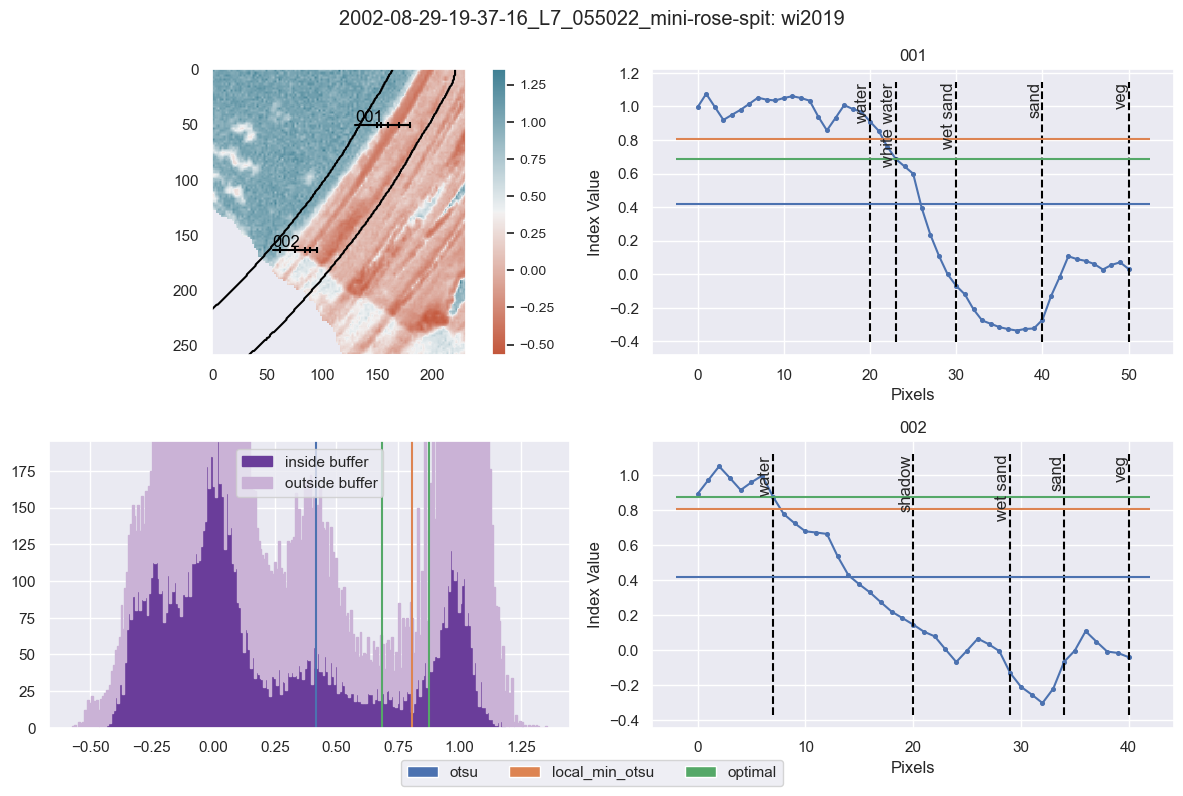

In [29]:
t, b_points, b_labs, sl_points, t_labs = get_image_plotting_params(sitename, im_idx)
title=fn_to_title(fns[im_idx][0], sitename)
samples = sample_ms(ims[im_idx], t)
print(title)

index_functions = [
    mndwi,
    # ndwi,
    # awei_ns,
    # awei_sh,
    # scowi,
    # wi2015,
    # andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
threshold_functions = [
    otsu,
    local_min_otsu
]

plot_indices(
    im=ims[im_idx],
    title=title,
    samples=samples,
    transects=t,
    boundary_points=b_points,
    boundary_labels=b_labs,
    transect_labels=t_labs,
    shoreline_points=sl_points,
    cloud_mask=cloud_masks[im_idx],
    im_buffer=im_buffers[im_idx],
    ind_fns=index_functions,
    thresh_fns=threshold_functions
)

2016-08-10-18-42-50_S2_15XWC_gas-cliff


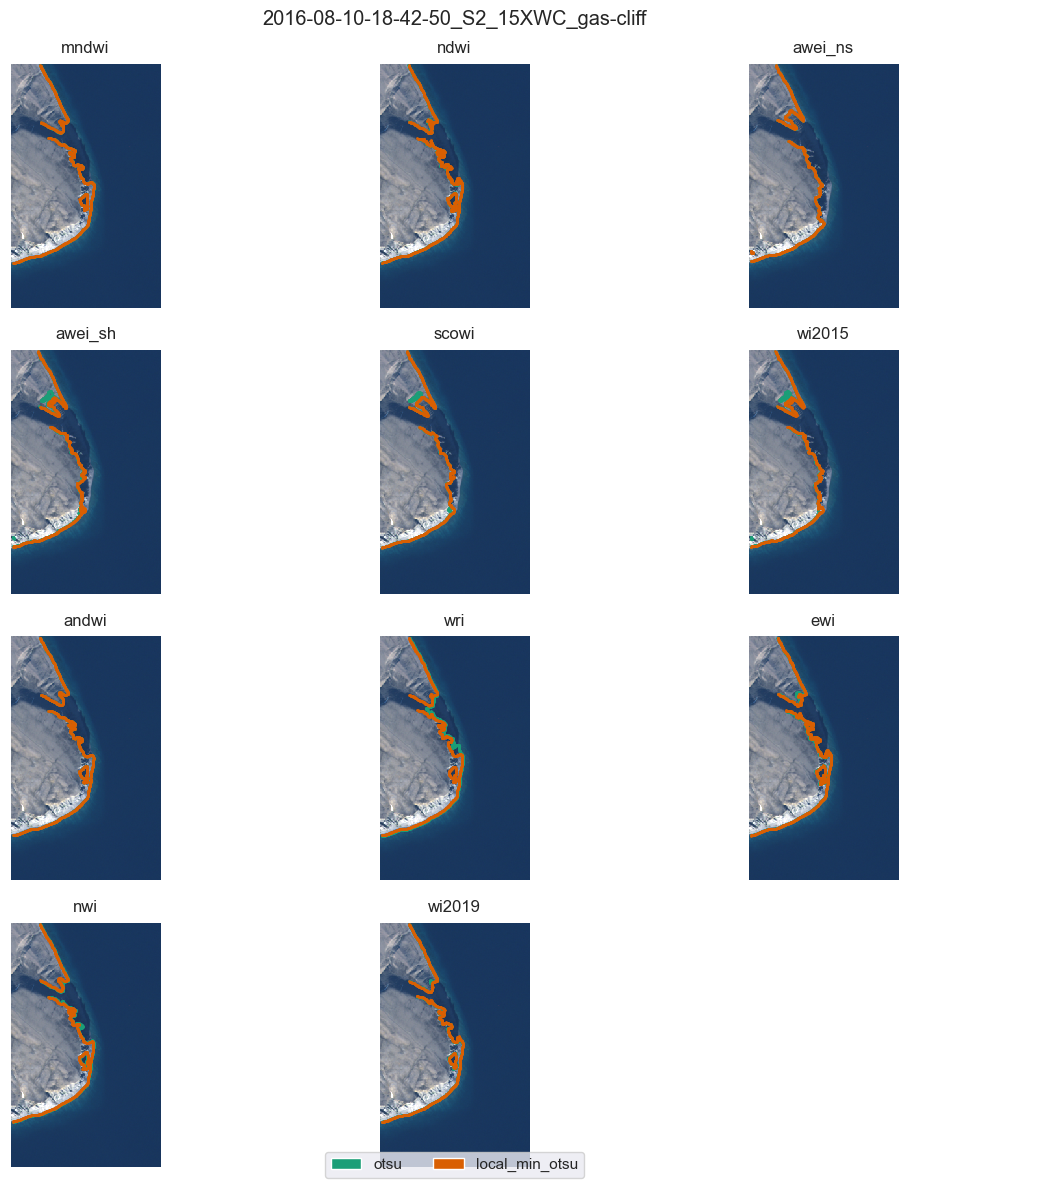

In [10]:
title=fn_to_title(fns[im_idx][0], sitename)
print(title)
index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
threshold_functions = [
    otsu,
    local_min_otsu
]
plot_extractions(
    ims[im_idx],
    title,
    index_functions,
    threshold_functions,
    cloud_masks[im_idx],
    im_buffers[im_idx],
    im_nodatas[im_idx],
    georefs[im_idx],
    im_epsgs[im_idx],
    buffer_settings
)

In [30]:
index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
threshold_functions = [
    otsu,
    local_min_otsu
]
save_all_plots(sitename, fns, ims, cloud_masks, im_buffers, im_nodatas, georefs, im_epsgs, index_functions, threshold_functions, buffer_settings, output_dir)